In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.manifold import TSNE
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from wordcloud import WordCloud
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, homogeneity_score
from charset_normalizer import from_path

In [2]:
result = from_path("..\\..\\data\\collocations\\processed_collocations_set_from_the_supervisor.csv").best()

df = pd.read_csv("..\\..\\data\\collocations\\processed_collocations_set_from_the_supervisor.csv", encoding=result.encoding)

df

,DocumentName,OriginalCollocation,NormalizedCollocation,Frequency
0,VoenObozrenN_0001.t,западный блок,западный блок,2
1,VoenObozrenN_0001.t,беспилотный аппарат,беспилотный аппарат,1
2,VoenObozrenN_0001.t,борт судно,борт судна,1
3,VoenObozrenN_0001.t,высокий точность,высокая точность,1
4,VoenObozrenN_0001.t,высокий уровень технический оснащенность,высокий уровень технической оснащенности,1
...,...,...,...,...
132876,Voen_Obozren_060524_011094.t,флагманский дрон,флагманский дрон,1
132877,Voen_Obozren_060524_011094.t,флагманский дрон разведчик,флагманский дрон-разведчик,1
132878,Voen_Obozren_060524_011094.t,фортификационный вооружение,фортификационное вооружение,1
132879,Voen_Obozren_060524_011094.t,человеческий ошибка,человеческая ошибка,1


In [3]:
df['Frequency'] = df['Frequency'].astype(int)

In [4]:
df["FrequencyInText"] = df.groupby(["DocumentName", "NormalizedCollocation"])["NormalizedCollocation"].transform("count")
df["FrequencyInCorpus"] = df.groupby("NormalizedCollocation")["NormalizedCollocation"].transform("count")

df

,DocumentName,OriginalCollocation,NormalizedCollocation,Frequency,FrequencyInText,FrequencyInCorpus
0,VoenObozrenN_0001.t,западный блок,западный блок,2,1,4
1,VoenObozrenN_0001.t,беспилотный аппарат,беспилотный аппарат,1,1,33
2,VoenObozrenN_0001.t,борт судно,борт судна,1,1,2
3,VoenObozrenN_0001.t,высокий точность,высокая точность,1,1,20
4,VoenObozrenN_0001.t,высокий уровень технический оснащенность,высокий уровень технической оснащенности,1,1,2
...,...,...,...,...,...,...
132876,Voen_Obozren_060524_011094.t,флагманский дрон,флагманский дрон,1,1,1
132877,Voen_Obozren_060524_011094.t,флагманский дрон разведчик,флагманский дрон-разведчик,1,1,1
132878,Voen_Obozren_060524_011094.t,фортификационный вооружение,фортификационное вооружение,1,1,1
132879,Voen_Obozren_060524_011094.t,человеческий ошибка,человеческая ошибка,1,1,1


In [5]:
df = df[df["FrequencyInCorpus"] > 1]
df

,DocumentName,OriginalCollocation,NormalizedCollocation,Frequency,FrequencyInText,FrequencyInCorpus
0,VoenObozrenN_0001.t,западный блок,западный блок,2,1,4
1,VoenObozrenN_0001.t,беспилотный аппарат,беспилотный аппарат,1,1,33
2,VoenObozrenN_0001.t,борт судно,борт судна,1,1,2
3,VoenObozrenN_0001.t,высокий точность,высокая точность,1,1,20
4,VoenObozrenN_0001.t,высокий уровень технический оснащенность,высокий уровень технической оснащенности,1,1,2
...,...,...,...,...,...,...
132869,Voen_Obozren_060524_011094.t,ударный дрон,ударный дрон,1,1,13
132870,Voen_Obozren_060524_011094.t,украинский дрон,украинский дрон,1,1,2
132872,Voen_Obozren_060524_011094.t,управление со,управление СО,1,1,4
132873,Voen_Obozren_060524_011094.t,усиление сигнал,усиление сигнала,1,1,2


In [6]:
doc_word_matrix = df.pivot_table(
    index='DocumentName',
    columns='NormalizedCollocation',
    values='Frequency',
    aggfunc='sum',
    fill_value=0
)

doc_word_matrix

NormalizedCollocation,"""Баба-Яга""","""Венгард""","""Гелиос-РЛД""","""Иван Грен""","""Клавесин 1РЭ""","""Князь Пожарский""","""Комета-М""","""Морской сборник""","""Панцирь-С1Э""","""Свирель""",...,ядерный удар,ядерный удар по Москве,ядерный чемоданчик,ядерный шантаж,якорная мина,японские военные,японское внешнеполитическое ведомство,яркий пример,ясное небо,ящик Пандоры
DocumentName,,,,,,,,,,,,,,,,,,,,,
VoenObozrenN_0001.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozrenN_0002.t,0,1,0,0,0,0,0,0,0,0,...,10,2,0,0,0,0,0,0,0,0
VoenObozrenN_0003.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozrenN_0004.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
VoenObozrenN_0005.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Voen_Obozren_060524_011090.t,0,0,0,0,0,0,0,0,0,0,...,2,0,0,1,0,0,0,0,0,0
Voen_Obozren_060524_011091.t,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Voen_Obozren_060524_011092.t,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0


In [7]:
transformer = TfidfTransformer()
tfidf_matrix = transformer.fit_transform(doc_word_matrix)
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=doc_word_matrix.index, columns=doc_word_matrix.index)
similarity_df.to_csv("..\\..\\data\\collocations\\cosine_similarity_matrix.csv", index=True)
similarity_df

DocumentName,VoenObozrenN_0001.t,VoenObozrenN_0002.t,VoenObozrenN_0003.t,VoenObozrenN_0004.t,VoenObozrenN_0005.t,VoenObozrenN_0006.t,VoenObozrenN_0007.t,VoenObozrenN_0008.t,VoenObozrenN_0009.t,VoenObozrenN_0010.t,...,Voen_Obozren_060524_011085.t,Voen_Obozren_060524_011086.t,Voen_Obozren_060524_011087.t,Voen_Obozren_060524_011088.t,Voen_Obozren_060524_011089.t,Voen_Obozren_060524_011090.t,Voen_Obozren_060524_011091.t,Voen_Obozren_060524_011092.t,Voen_Obozren_060524_011093.t,Voen_Obozren_060524_011094.t
DocumentName,,,,,,,,,,,,,,,,,,,,,
VoenObozrenN_0001.t,1.000000,0.000000,0.000000,0.021329,0.004878,0.000000,0.000000,0.000000,0.000000,0.004549,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001578,0.000000
VoenObozrenN_0002.t,0.000000,1.000000,0.000000,0.014692,0.003312,0.000000,0.003145,0.021976,0.008064,0.000000,...,0.012510,0.000000,0.000000,0.067305,0.047889,0.092104,0.027613,0.148570,0.059150,0.004341
VoenObozrenN_0003.t,0.000000,0.000000,1.000000,0.000000,0.000000,0.005400,0.000000,0.005277,0.013565,0.066879,...,0.000000,0.006868,0.010364,0.000000,0.002851,0.006708,0.000000,0.000000,0.000000,0.049783
VoenObozrenN_0004.t,0.021329,0.014692,0.000000,1.000000,0.067238,0.001367,0.000000,0.008237,0.005585,0.018785,...,0.005198,0.000000,0.000000,0.000000,0.000000,0.006366,0.000000,0.006934,0.007895,0.004516
VoenObozrenN_0005.t,0.004878,0.003312,0.000000,0.067238,1.000000,0.000000,0.000000,0.000000,0.011789,0.008863,...,0.000000,0.000000,0.047590,0.000000,0.000000,0.000000,0.000000,0.000000,0.003076,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Voen_Obozren_060524_011090.t,0.000000,0.092104,0.006708,0.006366,0.000000,0.000000,0.000000,0.003466,0.000000,0.000000,...,0.000000,0.000000,0.007363,0.032665,0.108647,1.000000,0.004455,0.060317,0.012140,0.000000
Voen_Obozren_060524_011091.t,0.000000,0.027613,0.000000,0.000000,0.000000,0.000000,0.000000,0.008253,0.000000,0.000000,...,0.000000,0.021856,0.000000,0.010031,0.033618,0.004455,1.000000,0.068178,0.000000,0.000000
Voen_Obozren_060524_011092.t,0.000000,0.148570,0.000000,0.006934,0.000000,0.005991,0.000000,0.006342,0.014261,0.002027,...,0.000000,0.000000,0.010611,0.063645,0.186125,0.060317,0.068178,1.000000,0.015354,0.001603


In [8]:
def save_clusters(labels, method_name):
    cluster_df = pd.DataFrame({"Document": doc_word_matrix.index, "Cluster": labels})
    cluster_df.to_csv(f"..\\..\\data\\collocations\\{method_name}_clusters.csv", index=False)

def save_cluster_centers(tfidf_matrix, labels, method_name):
    unique_clusters = np.unique(labels)
    cluster_centers = []

    for cluster in unique_clusters:
        if cluster == -1:
            continue
        cluster_indices = np.where(labels == cluster)[0]
        cluster_vectors = tfidf_matrix[cluster_indices].toarray()
        center_idx = np.argmin(cdist([cluster_vectors.mean(axis=0)], cluster_vectors)[0])
        central_file = doc_word_matrix.index[cluster_indices[center_idx]]
        cluster_centers.append((cluster, central_file))

    centers_df = pd.DataFrame(cluster_centers, columns=["Cluster", "Central_File"])
    centers_df.to_csv(f"..\\..\\data\\collocations\\{method_name}_cluster_centers.csv", index=False)

In [9]:
k = 150
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(tfidf_matrix)
save_clusters(kmeans_labels, "kmeans")
save_cluster_centers(tfidf_matrix, kmeans_labels, "kmeans")

In [10]:
eps = 0.6
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric="cosine")
dbscan_labels = dbscan.fit_predict(tfidf_matrix)
save_clusters(dbscan_labels, "dbscan")
save_cluster_centers(tfidf_matrix, dbscan_labels, "dbscan")

In [11]:
n_clusters_agglo = 100
agglo = AgglomerativeClustering(n_clusters=n_clusters_agglo, metric="cosine", linkage="average")
agglo_labels = agglo.fit_predict(tfidf_matrix.toarray())
save_clusters(agglo_labels, "agglomerative")
save_cluster_centers(tfidf_matrix, agglo_labels, "agglomerative")

In [12]:
def load_clusters(file_name):
    return pd.read_csv(file_name)

In [13]:
kmeans_clusters = load_clusters("..\\..\\data\\collocations\\kmeans_clusters.csv")
dbscan_clusters = load_clusters("..\\..\\data\\collocations\\dbscan_clusters.csv")
agglo_clusters = load_clusters("..\\..\\data\\collocations\\agglomerative_clusters.csv")

kmeans_cluster_centers = load_clusters("..\\..\\data\\collocations\\kmeans_cluster_centers.csv")
dbscan_cluster_centers = load_clusters("..\\..\\data\\collocations\\dbscan_cluster_centers.csv")
agglo_cluster_centers = load_clusters("..\\..\\data\\collocations\\agglomerative_cluster_centers.csv")

In [14]:
def visualize_clusters(labels, tfidf_matrix, method_name):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, metric='cosine')
    tsne_res = tsne.fit_transform(tfidf_matrix.toarray())

    unique_labels = np.unique(labels)
    cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=labels, cmap=cmap, s=10, alpha=0.9)
    
    max_label = max(unique_labels)
    tick_labels = list(range(0, max_label + 4, 4))
    plt.colorbar(scatter, label=f'{method_name} Cluster', ticks=tick_labels)
    
    plt.title(f't-SNE визуализация кластеров {method_name}')
    plt.xlabel('t-SNE измерение 1')
    plt.ylabel('t-SNE измерение 2')
    
    plt.grid(True)
    plt.show()

    unique_clusters, counts = np.unique(labels, return_counts=True)
    print(f"{method_name} кластеры:", dict(zip(unique_clusters, counts)))

def generate_word_cloud(cluster_label, cluster_df, method_name):
    cluster_files = cluster_df[cluster_df['Cluster'] == cluster_label]['Document']
    print(f"Файлы в кластере {cluster_label} ({method_name}):")
    for f in cluster_files:
        print(f)

    for doc_name in cluster_files:
        doc_data = df[df['DocumentName'] == doc_name]
        word_freq = dict(zip(doc_data['NormalizedCollocation'], doc_data['Frequency']))
        wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Облако слов для {doc_name}')
        plt.show()

def evaluate_clustering_quality(tfidf_matrix, labels, method_name):
    unique_labels = np.unique(labels)
    
    if len(unique_labels) > 1:
        silhouette = silhouette_score(tfidf_matrix, labels, metric='cosine')
        davies_bouldin = davies_bouldin_score(tfidf_matrix.toarray(), labels)
        homogeneity = homogeneity_score(true_labels, labels) if 'true_labels' in globals() else None
    else:
        silhouette, davies_bouldin, homogeneity = None, None, None
    
    print(f"Метрики качества для {method_name}:")
    print(f"  - Силуэтный коэффициент: {silhouette}")
    print(f"  - Коэффициент Давиеса-Боулдина: {davies_bouldin}")
    if homogeneity is not None:
        print(f"  - Гомогенность: {homogeneity}")

In [15]:
transformer = TfidfTransformer()
tfidf_matrix = transformer.fit_transform(doc_word_matrix)

C:\Users\Juliana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Juliana\AppData\Local\Temp\ipykernel_21664\3865796362.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)


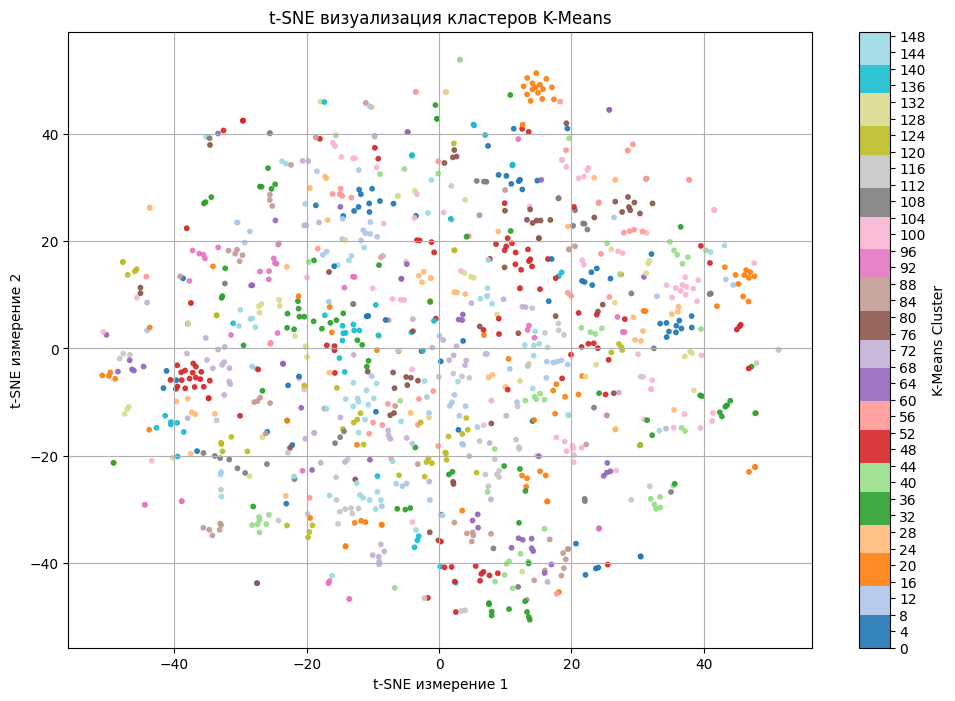

K-Means кластеры: {0: 7, 1: 7, 2: 9, 3: 6, 4: 4, 5: 6, 6: 16, 7: 12, 8: 12, 9: 6, 10: 5, 11: 19, 12: 4, 13: 5, 14: 3, 15: 14, 16: 11, 17: 7, 18: 5, 19: 8, 20: 16, 21: 3, 22: 10, 23: 5, 24: 8, 25: 9, 26: 8, 27: 7, 28: 5, 29: 4, 30: 3, 31: 5, 32: 10, 33: 18, 34: 5, 35: 8, 36: 5, 37: 22, 38: 12, 39: 6, 40: 8, 41: 6, 42: 7, 43: 5, 44: 9, 45: 6, 46: 7, 47: 20, 48: 12, 49: 4, 50: 20, 51: 5, 52: 21, 53: 9, 54: 9, 55: 8, 56: 5, 57: 5, 58: 5, 59: 3, 60: 5, 61: 3, 62: 10, 63: 4, 64: 6, 65: 2, 66: 3, 67: 11, 68: 17, 69: 4, 70: 8, 71: 6, 72: 5, 73: 11, 74: 8, 75: 12, 76: 12, 77: 10, 78: 3, 79: 6, 80: 4, 81: 5, 82: 8, 83: 4, 84: 6, 85: 9, 86: 6, 87: 12, 88: 3, 89: 7, 90: 11, 91: 5, 92: 3, 93: 5, 94: 5, 95: 3, 96: 4, 97: 16, 98: 8, 99: 5, 100: 7, 101: 11, 102: 17, 103: 5, 104: 9, 105: 2, 106: 8, 107: 7, 108: 3, 109: 6, 110: 4, 111: 8, 112: 5, 113: 4, 114: 9, 115: 3, 116: 8, 117: 11, 118: 3, 119: 5, 120: 17, 121: 4, 122: 6, 123: 5, 124: 7, 125: 2, 126: 5, 127: 3, 128: 5, 129: 6, 130: 5, 131: 5, 132: 

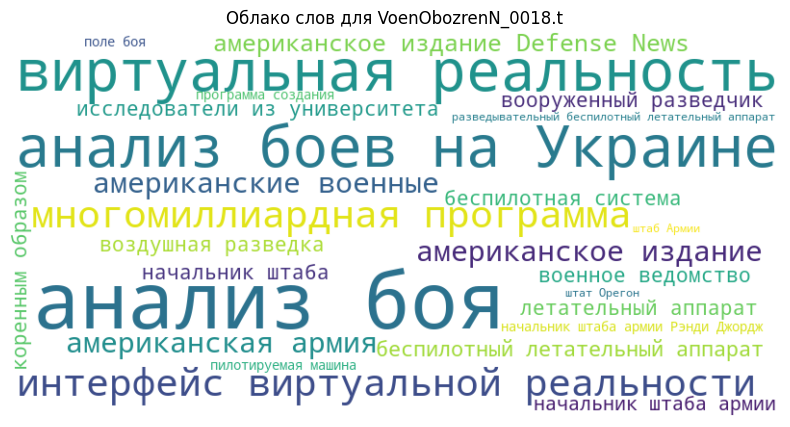

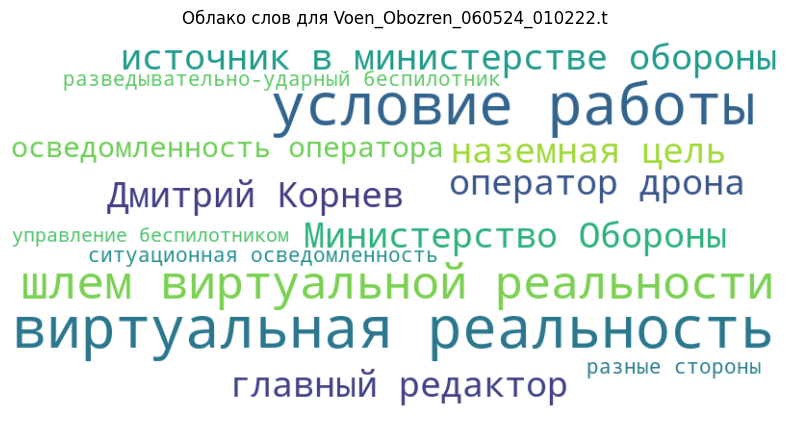

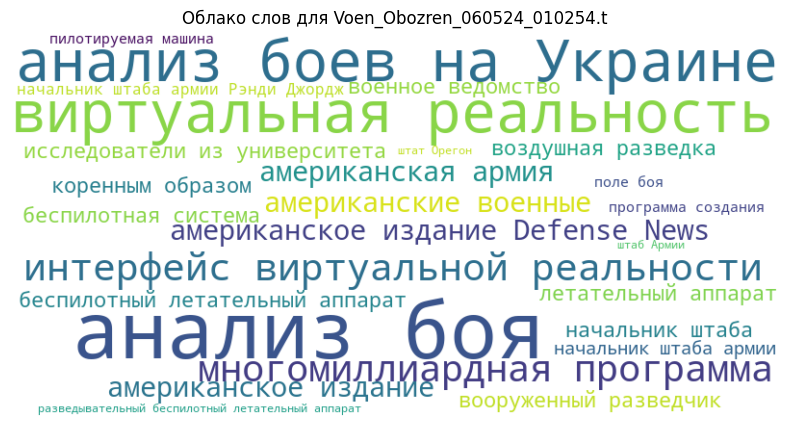

,Document,Cluster
0,VoenObozrenN_0001.t,55
1,VoenObozrenN_0002.t,16
2,VoenObozrenN_0003.t,101
3,VoenObozrenN_0004.t,111
4,VoenObozrenN_0005.t,118
...,...,...
1108,Voen_Obozren_060524_011090.t,16
1109,Voen_Obozren_060524_011091.t,117
1110,Voen_Obozren_060524_011092.t,117
1111,Voen_Obozren_060524_011093.t,120


In [16]:
visualize_clusters(kmeans_clusters['Cluster'].values, tfidf_matrix, "K-Means")
generate_word_cloud(21, kmeans_clusters, "K-Means")
kmeans_clusters

In [17]:
kmeans_cluster_centers[:25]

,Cluster,Central_File
0,0,VoenObozrenN_0007.t
1,1,Voen_Obozren_060524_010044.t
2,2,Voen_Obozren_060524_010217.t
3,3,Voen_Obozren_060524_010319.t
4,4,Voen_Obozren_060524_010642.t
5,5,Voen_Obozren_060524_010658.t
6,6,Voen_Obozren_060524_011001.t
7,7,Voen_Obozren_060524_010559.t
8,8,Voen_Obozren_060524_011062.t
9,9,Voen_Obozren_060524_011039.t


In [18]:
evaluate_clustering_quality(tfidf_matrix, kmeans_labels, "K-Means")

Метрики качества для K-Means:
  - Силуэтный коэффициент: 0.048082769507839095
  - Коэффициент Давиеса-Боулдина: 3.3109642468118894


C:\Users\Juliana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Juliana\AppData\Local\Temp\ipykernel_21664\3865796362.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)


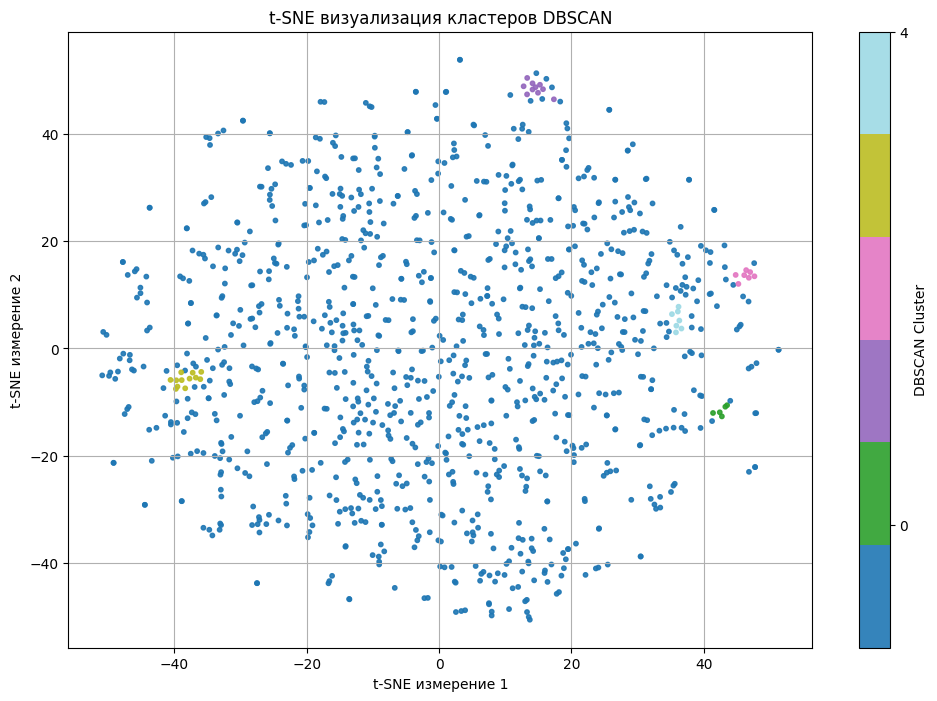

DBSCAN кластеры: {-1: 1072, 0: 5, 1: 10, 2: 7, 3: 12, 4: 7}
Файлы в кластере 8 (DBSCAN):


,Document,Cluster
0,VoenObozrenN_0001.t,-1
1,VoenObozrenN_0002.t,-1
2,VoenObozrenN_0003.t,-1
3,VoenObozrenN_0004.t,-1
4,VoenObozrenN_0005.t,-1
...,...,...
1108,Voen_Obozren_060524_011090.t,-1
1109,Voen_Obozren_060524_011091.t,-1
1110,Voen_Obozren_060524_011092.t,-1
1111,Voen_Obozren_060524_011093.t,-1


In [19]:
visualize_clusters(dbscan_clusters['Cluster'].values, tfidf_matrix, "DBSCAN")
generate_word_cloud(8, dbscan_clusters, "DBSCAN")
dbscan_clusters

In [20]:
dbscan_cluster_centers

,Cluster,Central_File
0,0,Voen_Obozren_060524_010028.t
1,1,Voen_Obozren_060524_010453.t
2,2,Voen_Obozren_060524_010517.t
3,3,Voen_Obozren_060524_010622.t
4,4,Voen_Obozren_060524_010918.t


In [21]:
evaluate_clustering_quality(tfidf_matrix, dbscan_labels, "DBSCAN")

Метрики качества для DBSCAN:
  - Силуэтный коэффициент: -0.0026949302317105443
  - Коэффициент Давиеса-Боулдина: 2.482953284088082


C:\Users\Juliana\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
C:\Users\Juliana\AppData\Local\Temp\ipykernel_21664\3865796362.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = ListedColormap(plt.cm.get_cmap('tab20', len(unique_labels)).colors)


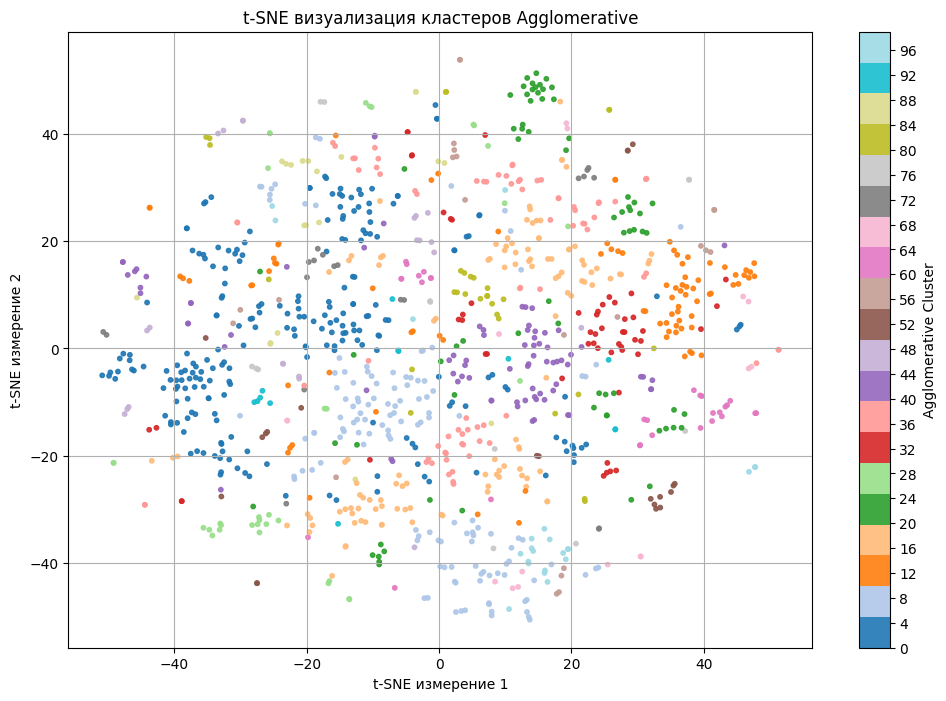

Agglomerative кластеры: {0: 40, 1: 83, 2: 84, 3: 17, 4: 7, 5: 3, 6: 13, 7: 41, 8: 64, 9: 10, 10: 9, 11: 10, 12: 53, 13: 9, 14: 6, 15: 50, 16: 25, 17: 3, 18: 34, 19: 6, 20: 19, 21: 22, 22: 18, 23: 9, 24: 3, 25: 6, 26: 4, 27: 4, 28: 6, 29: 14, 30: 27, 31: 5, 32: 8, 33: 4, 34: 10, 35: 11, 36: 32, 37: 27, 38: 5, 39: 2, 40: 6, 41: 14, 42: 11, 43: 42, 44: 7, 45: 5, 46: 5, 47: 4, 48: 3, 49: 5, 50: 2, 51: 1, 52: 6, 53: 3, 54: 9, 55: 4, 56: 6, 57: 7, 58: 3, 59: 2, 60: 2, 61: 13, 62: 5, 63: 1, 64: 9, 65: 4, 66: 2, 67: 3, 68: 2, 69: 5, 70: 7, 71: 1, 72: 2, 73: 4, 74: 6, 75: 2, 76: 2, 77: 2, 78: 5, 79: 2, 80: 1, 81: 16, 82: 5, 83: 5, 84: 3, 85: 7, 86: 4, 87: 3, 88: 4, 89: 2, 90: 2, 91: 2, 92: 2, 93: 2, 94: 5, 95: 1, 96: 2, 97: 3, 98: 15, 99: 2}
Файлы в кластере 11 (Agglomerative):
Voen_Obozren_060524_010019.t
Voen_Obozren_060524_010277.t
Voen_Obozren_060524_010593.t
Voen_Obozren_060524_010595.t
Voen_Obozren_060524_010605.t
Voen_Obozren_060524_010911.t
Voen_Obozren_060524_010944.t
Voen_Obozren_0605

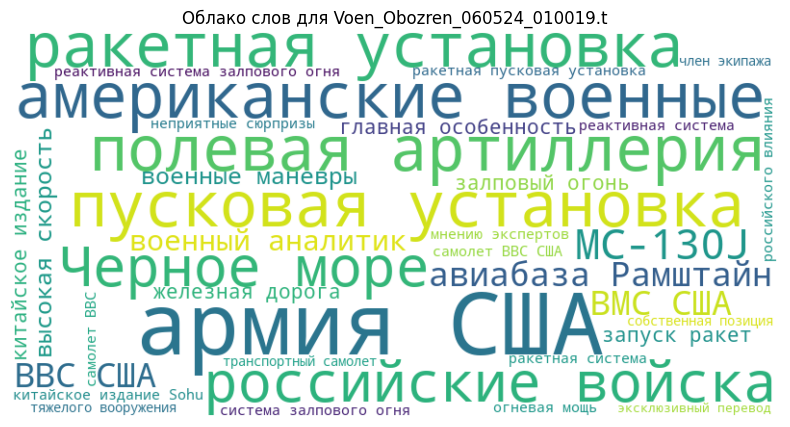

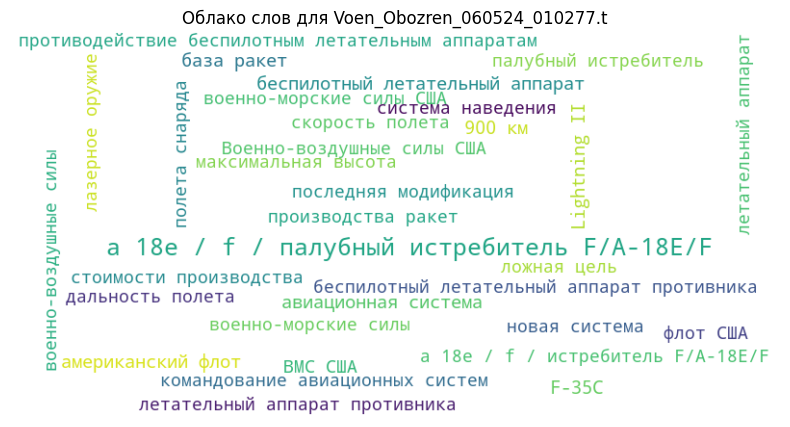

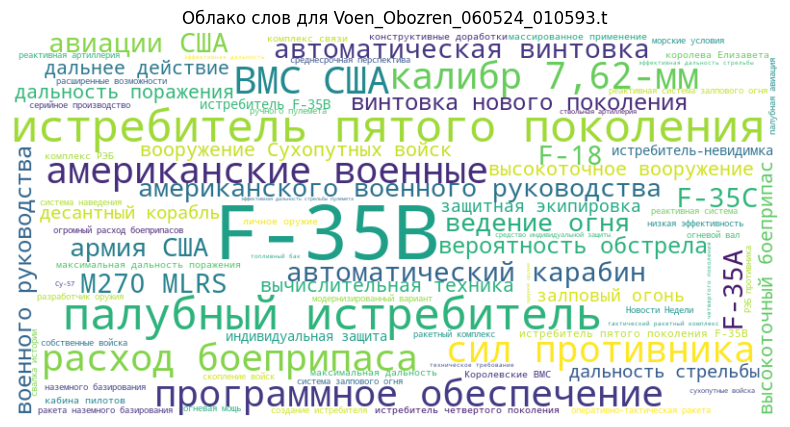

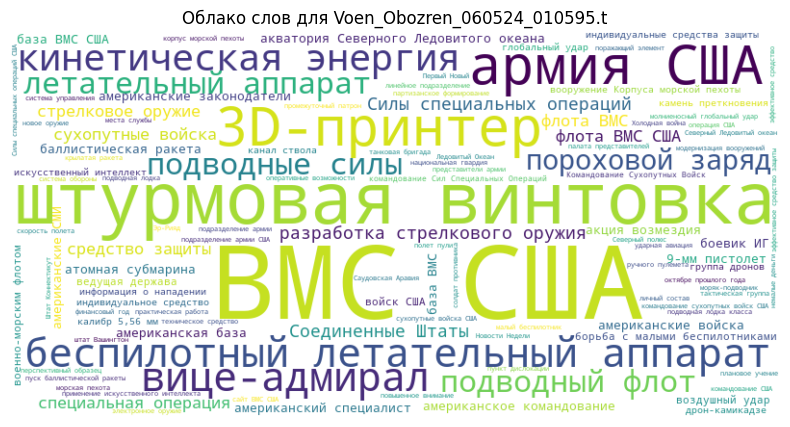

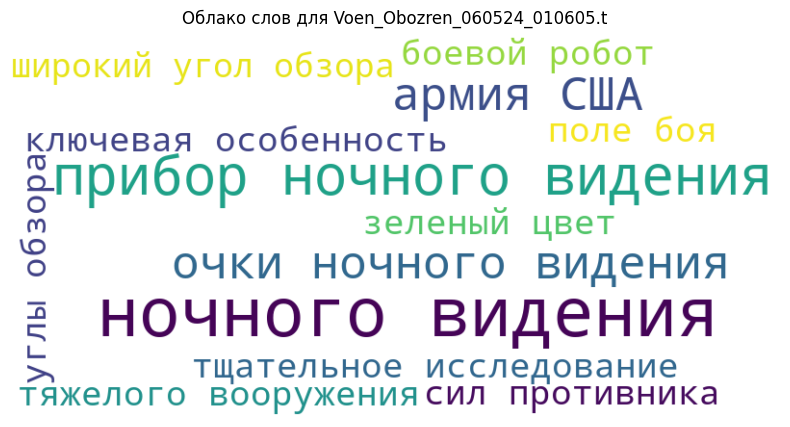

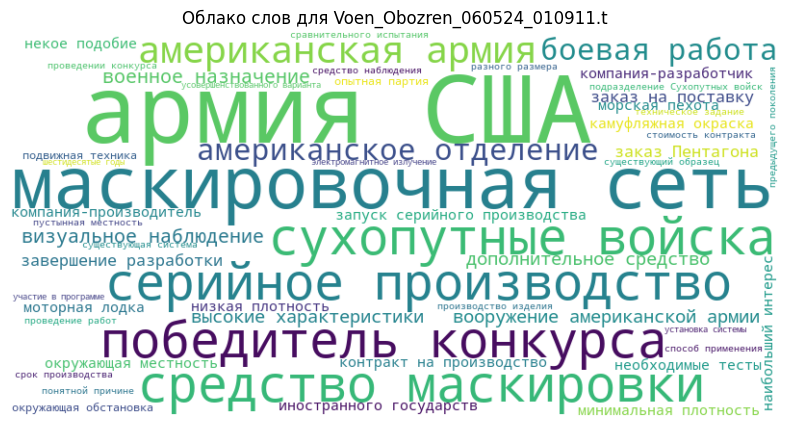

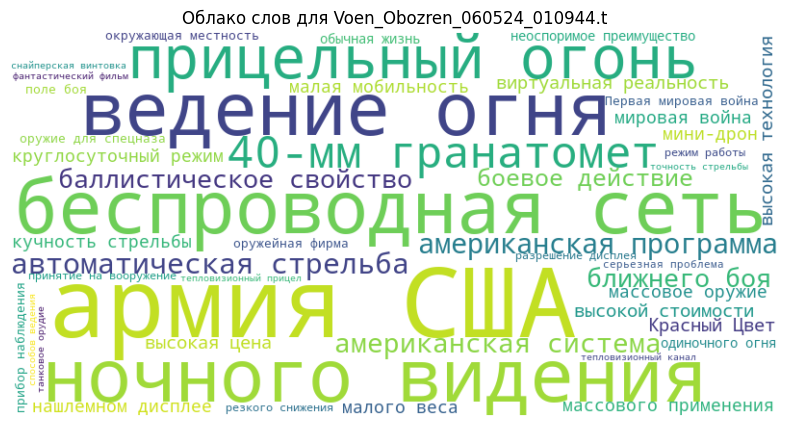

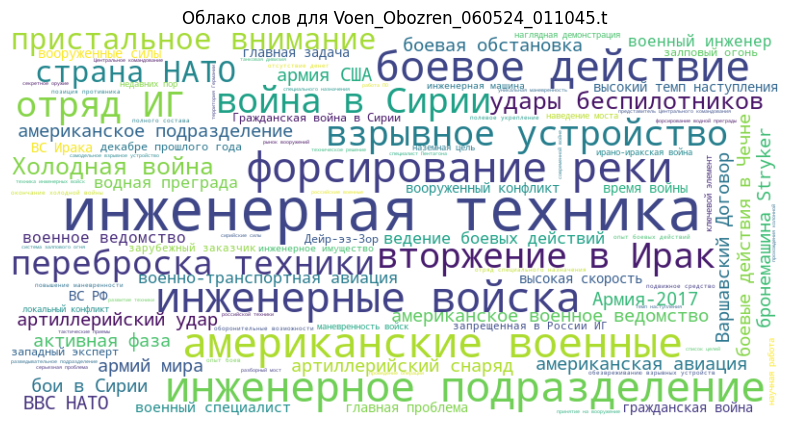

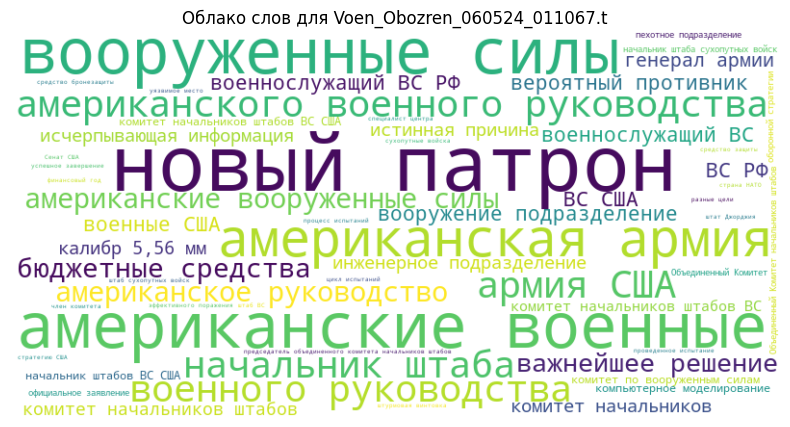

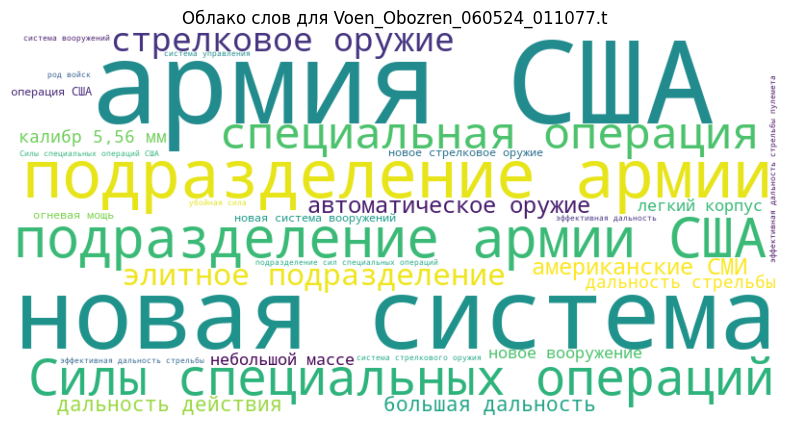

,Document,Cluster
0,VoenObozrenN_0001.t,79
1,VoenObozrenN_0002.t,18
2,VoenObozrenN_0003.t,15
3,VoenObozrenN_0004.t,36
4,VoenObozrenN_0005.t,38
...,...,...
1108,Voen_Obozren_060524_011090.t,18
1109,Voen_Obozren_060524_011091.t,91
1110,Voen_Obozren_060524_011092.t,18
1111,Voen_Obozren_060524_011093.t,37


In [22]:
visualize_clusters(agglo_clusters['Cluster'].values, tfidf_matrix, "Agglomerative")
generate_word_cloud(11, agglo_clusters, "Agglomerative")
agglo_clusters

In [23]:
agglo_cluster_centers

,Cluster,Central_File
0,0,Voen_Obozren_060524_010088.t
1,1,Voen_Obozren_060524_010067.t
2,2,Voen_Obozren_060524_010700.t
3,3,Voen_Obozren_060524_010432.t
4,4,VoenObozrenN_0011.t
...,...,...
95,95,Voen_Obozren_060524_010576.t
96,96,Voen_Obozren_060524_010470.t
97,97,VoenObozrenN_0018.t
98,98,Voen_Obozren_060524_010780.t


In [24]:
evaluate_clustering_quality(tfidf_matrix, agglo_labels, "Agglomerative")

Метрики качества для Agglomerative:
  - Силуэтный коэффициент: 0.04050588143290054
  - Коэффициент Давиеса-Боулдина: 3.369605715603129


In [25]:
output_path = "..\\..\\data\\collocations\\dataprocessed_dataset.csv"
df.to_csv(output_path, index=False, encoding='windows-1251')
print(f"Данные успешно сохранены в {output_path}")

Данные успешно сохранены в ..\..\data\collocations\dataprocessed_dataset.csv


Каждая метрика качества кластеризации оценивает различные аспекты разбиения данных на кластеры:

### **Силуэтный коэффициент (`silhouette_score`)**
   - **Диапазон** от -1 до 1.
   - **Измеряет** насколько хорошо объекты внутри кластера схожи друг с другом и насколько далеки от объектов других кластеров.
   - **Интерпретация**
     - Близкое к **1** значение означает, что кластеры четко разделены.
     - **0** означает, что объекты на границе между кластерами.
     - Отрицательные значения (**< 0**) означают, что кластеры плохо разделены.

### **Коэффициент Давиеса-Боулдина (`davies_bouldin_score`)**
   - **Диапазон** от 0 до ∞ (чем меньше, тем лучше).
   - **Измеряет** среднее отношение внутрикластерной дисперсии к межкластерному расстоянию.
   - **Интерпретация**
     - Чем **меньше** значение, тем лучше кластеры разнесены и плотнее сгруппированы.
     - Высокие значения означают, что кластеры плохо разделены.

### **Гомогенность (`homogeneity_score`)**
   - **Диапазон** от 0 до 1.
   - **Измеряет** Насколько объекты одного класса (истинные метки, если известны) находятся в одном кластере.
   - **Интерпретация**
     - **1** – идеальная гомогенность (каждый кластер содержит объекты только одного класса).
     - **0** – полное перемешивание классов в кластерах.

### Вывод:
- **Силуэтный коэффициент** показывает, насколько отчетливо кластеры разделены.
- **Коэффициент Давиеса-Боулдина** оценивает компактность кластеров и их разнесенность.
- **Гомогенность** показывает, насколько кластеры соответствуют истинной разметке, если она известна.

Если кластеры хорошо разделены и структура данных выражена четко, ожидаются:
- Высокий **силуэтный коэффициент** (~0.5-1),
- Низкий **коэффициент Давиеса-Боулдина** (близко к 0),
- Высокая **гомогенность** (если известны истинные метки).